# 2020~2025 공공자전거 이용 분석과 재배치를 위한 수요예측 모델


- 020_공공자전거_월별이용분석.ipynb(1년치 패턴 분석)에 이어서, 여러 해의 데이터로 자치구별 수요를 예측하고 재배치 계획까지 만드는 노트북입니다.

- 예측 목표: 자치구별 일별 대여량과 일별 반납량 → 두 값의 차이(순유입)로 "어느 구에 자전거가 부족·과잉할지" 예측

- HORIZON = 7(7일 뒤 예측)로 두고, 7일 이전 정보만 특성으로 사용합니다. 그러면 오늘까지의 데이터만으로 앞으로 7일을 한 번에 예측할 수 있습니다. (내일만 예측하려면 HORIZON = 1)

In [1]:
import os, re, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')


In [2]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [3]:
BASE_DIR = r"C:\ai\source\09_project\00_data"            
OUT_DIR  = r"C:\ai\source\09_project\02_forecast"        
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
HORIZON     = 7                       
VALID_START = '2024-01-01'            
TEST_START  = '2025-01-01'            


In [5]:
SEASON_ORDER = ['봄', '여름', '가을', '겨울']
SEASON_COLOR = {'봄': '#8BC34A', '여름': '#FF7043', '가을': '#FFB300', '겨울': '#42A5F5'}
WEEK_ORDER   = ['월', '화', '수', '목', '금', '토', '일']

In [6]:
def to_season(m):
    return {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
            6: '여름', 7: '여름', 8: '여름'}.get(m, '가을')

def save(name):
    plt.savefig(os.path.join(OUT_DIR, name), dpi=150, bbox_inches='tight')

files = sorted(glob.glob(os.path.join(BASE_DIR, '**', '*_merge.csv'), recursive=True),
               key=lambda f: os.path.basename(f))
files = [f for f in files if re.match(r'^\d{4}_merge\.csv$', os.path.basename(f))]
yymm = pd.Series([os.path.basename(f)[:4] for f in files])
print('파일 수:', len(files))
print(yymm.groupby(yymm.str[:2]).apply(lambda s: ', '.join(s.str[2:])).rename('연도별 월'))

파일 수: 72
20    01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
21    01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
22    01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
23    01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
24    01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
25    01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12
Name: 연도별 월, dtype: object


# 파일별 집계 

- 연도마다 컬럼 이름의 띄어쓰기가 다를 수 있어서(반납 자치구, 반납자치구) 컬럼 이름의 공백을 모두 지우고 사용합니다.
- 날짜 형식도 해마다 다를 수 있어서(2020-01-01 0:01, 2020-02-01 00:00:20) 정규표현식으로 읽습니다.
- 파일마다 아래 3개 표로 줄입니다. 반납량은 반납일시의 날짜와 반납 자치구 기준으로 셉니다.

In [7]:
def parse_dt(s):
    p = s.astype(str).str.extract(r'(\d{4})-(\d{1,2})-(\d{1,2})\s+(\d{1,2}):(\d{2})')
    p = p.astype(float)
    return pd.to_datetime(dict(year=p[0], month=p[1], day=p[2], hour=p[3], minute=p[4]), errors='coerce')

def aggregate_file(path):
    t = time.time()
    df = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    df.columns = df.columns.str.replace(' ', '')
    rent_dt = parse_dt(df['대여일시'])
    ret_dt  = parse_dt(df['반납일시'])

    rent = (pd.DataFrame({'자치구': df['대여자치구'], 'date': rent_dt.dt.normalize()})
              .dropna().groupby(['자치구', 'date']).size().reset_index(name='rent'))
    ret = (pd.DataFrame({'자치구': df['반납자치구'], 'date': ret_dt.dt.normalize()})
             .dropna().groupby(['자치구', 'date']).size().reset_index(name='ret'))
    city_hour = (pd.DataFrame({'date': rent_dt.dt.normalize(), 'hour': rent_dt.dt.hour})
                   .dropna().groupby(['date', 'hour']).size().reset_index(name='cnt'))
    print(f'{os.path.basename(path)}: {len(df):>10,}건, {time.time() - t:.1f}초')
    return rent, ret, city_hour

parts = [aggregate_file(f) for f in files]
rent, ret, city_hour = [pd.concat(p, ignore_index=True) for p in zip(*parts)]
del parts
rent = rent.groupby(['자치구', 'date'], as_index=False)['rent'].sum()
ret  = ret.groupby(['자치구', 'date'], as_index=False)['ret'].sum()
city_hour = city_hour.groupby(['date', 'hour'], as_index=False)['cnt'].sum()

rent.to_csv(os.path.join(OUT_DIR, 'agg_rent_daily.csv'), index=False, encoding='utf-8-sig')
ret.to_csv(os.path.join(OUT_DIR, 'agg_return_daily.csv'), index=False, encoding='utf-8-sig')
city_hour.to_csv(os.path.join(OUT_DIR, 'agg_city_hour.csv'), index=False, encoding='utf-8-sig')
print('총 대여:', f"{rent['rent'].sum():,}건")

2001_merge.csv:    360,671건, 3.4초
2002_merge.csv:    355,204건, 3.6초
2003_merge.csv:    634,374건, 6.6초
2004_merge.csv:    829,504건, 8.5초
2005_merge.csv:    885,244건, 9.3초
2006_merge.csv:  1,119,106건, 12.2초
2007_merge.csv:  1,141,541건, 12.6초
2008_merge.csv:    801,479건, 8.3초
2009_merge.csv:  1,347,503건, 14.3초
2010_merge.csv:  1,447,129건, 15.5초
2011_merge.csv:  1,018,113건, 10.6초
2012_merge.csv:    628,108건, 6.9초
2101_merge.csv:    433,248건, 4.3초
2102_merge.csv:    662,741건, 7.2초
2103_merge.csv:  1,187,353건, 12.3초
2104_merge.csv:  1,532,824건, 16.3초
2105_merge.csv:  1,409,282건, 14.8초
2106_merge.csv:  1,606,718건, 17.3초
2107_merge.csv:  1,644,289건, 17.1초
2108_merge.csv:  1,556,273건, 16.9초
2109_merge.csv:  1,863,787건, 19.3초
2110_merge.csv:  1,775,471건, 19.0초
2111_merge.csv:  1,435,940건, 15.0초
2112_merge.csv:    981,225건, 10.4초
2201_merge.csv:    769,173건, 8.2초
2202_merge.csv:    738,177건, 8.0초
2203_merge.csv:  1,328,171건, 15.3초
2204_merge.csv:  2,214,990건, 23.4초
2205_merge.csv:  2,823,784건, 30

# 자치구 × 날짜 패널

- 모든 자치구와 모든 날짜의 조합을 만들고 대여·반납 건수를 붙입니다. 기록이 없는 날은 0건입니다.
- 파일이 통째로 빠진 기간(서울시 전체 대여가 0인 날)은 0이 아니라 결측(NaN)으로 표시해서 제외.


In [ ]:
# rent = pd.read_csv(os.path.join(OUT_DIR, 'agg_rent_daily.csv'), parse_dates=['date'])
# ret  = pd.read_csv(os.path.join(OUT_DIR, 'agg_return_daily.csv'), parse_dates=['date'])
# city_hour = pd.read_csv(os.path.join(OUT_DIR, 'agg_city_hour.csv'), parse_dates=['date'])



In [8]:
GUS = sorted(rent['자치구'].unique())
start, end = rent['date'].min(), rent['date'].max()
grid = pd.MultiIndex.from_product([GUS, pd.date_range(start, end)], names=['자치구', 'date']).to_frame(index=False)
panel = (grid.merge(rent, on=['자치구', 'date'], how='left')
             .merge(ret, on=['자치구', 'date'], how='left')
             .fillna({'rent': 0, 'ret': 0}))

city_total = panel.groupby('date')['rent'].transform('sum')
panel.loc[city_total == 0, ['rent', 'ret']] = np.nan          # 데이터가 없는 날
panel['net'] = panel['ret'] - panel['rent']                    # 순유입 (+ 쌓임 / − 부족)

print(f'자치구 {len(GUS)}개, 기간 {start.date()} ~ {end.date()}, 패널 {len(panel):,}행')
missing_days = panel.loc[panel['rent'].isna(), 'date'].drop_duplicates()
print('데이터가 없는 날:', len(missing_days), '일',
      missing_days.dt.strftime('%Y-%m').value_counts().sort_index().to_dict() if len(missing_days) else '')

cover = panel.dropna().assign(연도=lambda d: d['date'].dt.year, 월=lambda d: d['date'].dt.month)
cover.pivot_table(index='연도', columns='월', values='date', aggfunc='nunique').fillna(0).astype(int)

자치구 25개, 기간 2020-01-01 ~ 2025-12-31, 패널 54,800행
데이터가 없는 날: 0 일 


월,1,2,3,4,5,6,7,8,9,10,11,12
연도,,,,,,,,,,,,
2020,31,29,31,30,31,30,31,31,30,31,30,31
2021,31,28,31,30,31,30,31,31,30,31,30,31
2022,31,28,31,30,31,30,31,31,30,31,30,31
2023,31,28,31,30,31,30,31,31,30,31,30,31
2024,31,29,31,30,31,30,31,31,30,31,30,31
2025,31,28,31,30,31,30,31,31,30,31,30,31


# 다년도 EDA 

## 연도별 월 이용량 비교

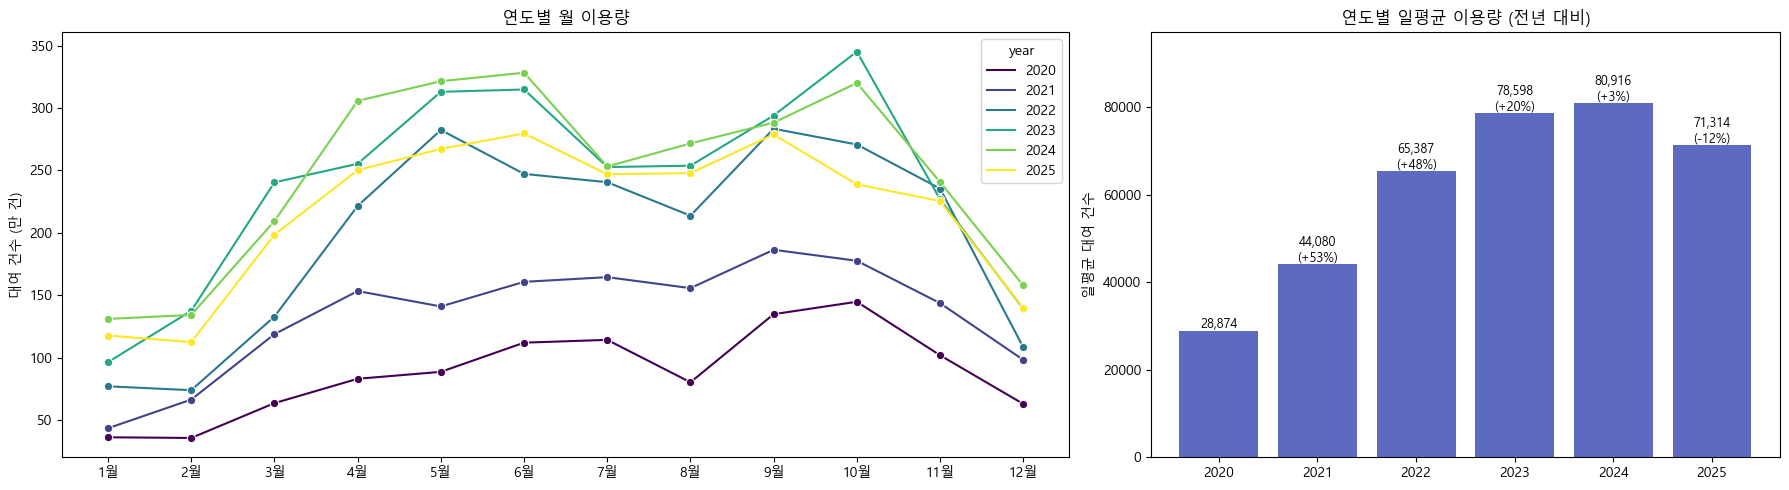

,total,days,일평균,증감률(%)
year,,,,
2020,10567976.0,366,28874.3,NaN
2021,16089151.0,365,44079.9,52.7
2022,23866286.0,365,65387.1,48.3
2023,28688220.0,365,78597.9,20.2
2024,29615283.0,366,80916.1,2.9
2025,26029536.0,365,71313.8,-11.9


In [9]:
city = panel.groupby('date', as_index=False)[['rent', 'ret']].sum(min_count=1)
city['year'], city['month'] = city['date'].dt.year, city['date'].dt.month
city['season'] = pd.Categorical(city['month'].map(to_season), SEASON_ORDER, ordered=True)

ym = city.groupby(['year', 'month'])['rent'].sum(min_count=1).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [1.6, 1]})
sns.lineplot(data=ym, x='month', y=ym['rent'] / 10000, hue='year', palette='viridis',
             marker='o', ax=axes[0])
axes[0].set_xticks(range(1, 13), [f'{m}월' for m in range(1, 13)])
axes[0].set_ylabel('대여 건수 (만 건)'); axes[0].set_xlabel(''); axes[0].set_title('연도별 월 이용량')

yearly = city.groupby('year').agg(total=('rent', 'sum'), days=('rent', 'count'))
yearly['일평균'] = yearly['total'] / yearly['days']
yearly['증감률(%)'] = yearly['일평균'].pct_change() * 100
bars = axes[1].bar(yearly.index.astype(str), yearly['일평균'], color='#5C6BC0')
axes[1].bar_label(bars, labels=[f'{v:,.0f}\n({g:+.0f}%)' if pd.notna(g) else f'{v:,.0f}'
                                for v, g in zip(yearly['일평균'], yearly['증감률(%)'])], fontsize=9)
axes[1].set_title('연도별 일평균 이용량 (전년 대비)'); axes[1].set_ylabel('일평균 대여 건수')
axes[1].set_ylim(0, yearly['일평균'].max() * 1.2)
plt.tight_layout(); save('F01_연도별월이용량.png'); plt.show()
yearly.round(1)

##  연도 × 월 히트맵과 계절별 일평균

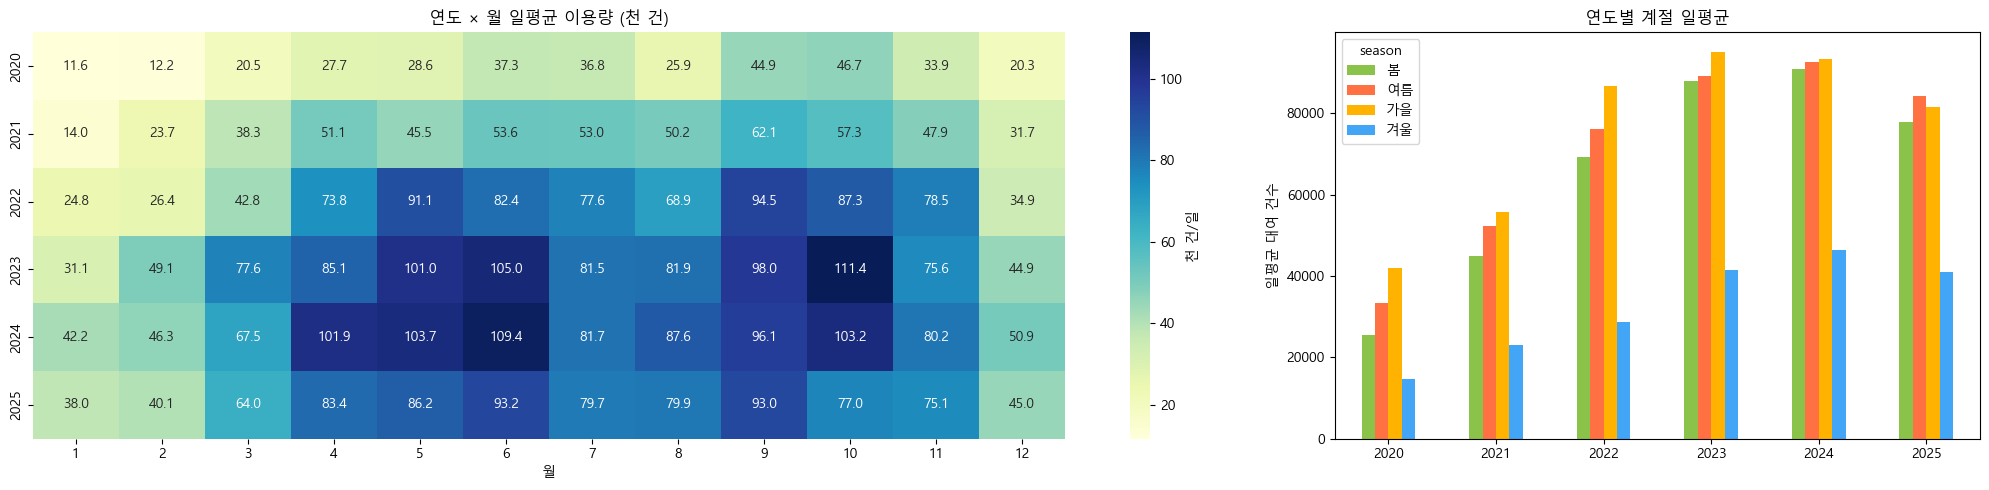

In [10]:
ym_avg = city.pivot_table(index='year', columns='month', values='rent', aggfunc='mean')
season_avg = city.pivot_table(index='year', columns='season', values='rent', aggfunc='mean', observed=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={'width_ratios': [2, 1]})
sns.heatmap(ym_avg / 1000, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[0], cbar_kws={'label': '천 건/일'})
axes[0].set_title('연도 × 월 일평균 이용량 (천 건)'); axes[0].set_xlabel('월'); axes[0].set_ylabel('')
season_avg.plot(kind='bar', ax=axes[1], color=[SEASON_COLOR[s] for s in SEASON_ORDER], rot=0)
axes[1].set_title('연도별 계절 일평균'); axes[1].set_xlabel(''); axes[1].set_ylabel('일평균 대여 건수')
plt.tight_layout(); save('F02_연도월히트맵.png'); plt.show()

In [11]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
DATA_DIR = os.path.join('00_data', '21')
files = sorted(glob.glob(os.path.join(DATA_DIR, '21??_merge.csv')))
assert files, f'{DATA_DIR}에서 파일을 찾지 못했습니다'
df = pd.concat((pd.read_csv(f, encoding='utf-8-sig') for f in files), ignore_index=True)
print(df.columns.tolist())    

['대여일시', '대여 대여소명', '반납일시', '반납 대여소명', '대여자치구', '반납 자치구', '대여요일']


In [13]:
GU_COL, DATE_COL, CNT_COL = '대여 대여소명', '반납일시', '대여일시'

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df['month'] = df[DATE_COL].dt.month

In [14]:
gu_month = df.pivot_table(index=GU_COL, columns='month', values=CNT_COL, aggfunc='sum')
gu_month = gu_month.loc[gu_month.sum(axis=1).sort_values(ascending=False).index]


In [16]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
MONTH_LABEL = [f'{m}월' for m in range(1, 13)]
def save(name, out_dir='figures'):
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, name), dpi=150, bbox_inches='tight')

gu_month.head()

month,1,2,3,4,5,6,7,8,9,10,11,12
대여 대여소명,,,,,,,,,,,,
(구)합정동 주민센터,2021-01-01 07:19:312021-01-01 16:53:242021-01-...,2021-02-01 08:47:322021-02-01 09:16:582021-02-...,2021-03-02 02:33:212021-03-02 07:49:592021-03-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
아차산역4번출구,2021-01-01 00:08:582021-01-01 09:03:312021-01-...,2021-02-01 07:52:052021-02-01 08:11:002021-02-...,2021-03-02 05:13:482021-03-02 08:02:232021-03-...,2021-03-31 22:20:322021-03-31 23:50:482021-04-...,2021-04-30 23:15:402021-05-01 00:26:222021-05-...,2021-06-01 00:36:522021-06-01 04:22:022021-06-...,2021-06-30 22:11:292021-07-01 00:42:482021-07-...,2021-08-01 00:11:442021-08-01 04:10:262021-08-...,2021-09-01 03:52:412021-09-01 04:22:082021-09-...,2021-10-01 00:30:132021-10-01 07:33:492021-10-...,2021-11-01 08:09:332021-11-01 08:36:172021-11-...,2021-12-01 00:43:022021-12-01 05:45:432021-12-...
아크로타워 스퀘어(영등포시장),2021-01-01 06:55:522021-01-01 13:08:062021-01-...,2021-02-01 00:50:082021-02-01 05:46:372021-02-...,2021-03-02 05:41:592021-03-02 07:36:202021-03-...,2021-04-01 00:23:192021-04-01 05:46:262021-04-...,2021-05-01 08:25:182021-05-01 08:45:112021-05-...,2021-05-31 23:56:522021-05-31 23:23:232021-05-...,2021-07-01 00:28:402021-07-01 05:27:372021-07-...,2021-08-01 01:29:312021-08-01 03:22:252021-08-...,2021-09-01 05:38:522021-09-01 07:08:012021-09-...,2021-10-01 00:35:172021-10-01 01:05:442021-10-...,2021-10-31 23:44:512021-11-01 02:13:042021-11-...,2021-12-01 04:07:362021-12-01 05:33:172021-12-...
아현문화건강센터,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-07 12:49:122021-12-07 23:05:392021-12-...
아현역 4번출구 앞,2021-01-01 05:58:502021-01-01 14:47:382021-01-...,2021-02-01 11:37:082021-02-01 13:57:272021-02-...,2021-03-02 13:33:532021-03-02 16:25:042021-03-...,2021-04-01 03:03:152021-04-01 07:52:462021-04-...,2021-04-30 23:39:052021-05-01 01:26:472021-05-...,2021-06-01 02:59:152021-06-01 02:22:002021-06-...,2021-07-01 00:30:162021-07-01 00:59:242021-07-...,2021-08-01 01:56:492021-08-01 03:20:432021-08-...,2021-09-01 08:08:192021-09-01 11:49:342021-09-...,2021-10-01 07:28:392021-10-01 07:47:212021-10-...,2021-11-01 08:23:502021-11-01 08:40:092021-11-...,2021-12-01 08:00:152021-12-01 08:21:212021-12-...


In [17]:
print(gu_month.shape)                          # 정상이면 (25, 12)
print(gu_month.index.tolist())                 # 구 이름 목록
gu_month[gu_month.isna().any(axis=1)]   

(2645, 12)
['(구)합정동 주민센터', '아차산역4번출구', '아크로타워 스퀘어(영등포시장)', '아현문화건강센터', '아현역 4번출구 앞', '안골마을입구', '안국동사거리(신)', '안국역 5번출구 앞', '안암2교 옆', '안암골벽산아파트(후문)', '안암로터리 버스정류장 앞', '안암역 3번 출구', '안양천합수부(현대3차아파트)', '안천중학교', '암사동 선사유적지', '암사역 3번출구(국민은행앞)', '암사정수센터교차로(강동롯데캐슬퍼스트아파트)', '압구정 한양 3차 아파트', '압구정나들목', '아크로리버뷰 부지 앞', '아차산역 3번출구', '신흥교(애견훈련소)', '아차산 휴먼시아 아파트 옆', '쌍문동 이안아파트 앞', '쌍문역 1번출구 주변', '쌍문역4번출구 주변', '쌍문현대1차아파트 108동 앞', '쌍용아파트', '쌍용아파트2단지 상가앞', '쌍용아파트2단지 정문', '쌍용예가(구청별관)', '쌍용플레티넘오피스텔', '아리랑시네센터 앞', '아만티호텔 앞', '아망떼마곡전시장', '아산병원 기숙사 부근', '아시아선수촌아파트 교차로', '아시아지하보도 14번 출구', '아시아지하보도 2번 출구', '아주중학교건너편', '압구정로데오역 6번출구', '압구정역 2번 출구 옆', '압구정역 교차로', '압구정파출소 앞', '양재역 10번 출구 앞', '양재역 3번출구 주변', '양재역 8번출구 앞', '양재이스타빌 앞', '양재전화국 사거리', '양재초등학교 맞은편', '양지근린공원앞', '양지사거리', '양지사거리(센트라스APT 115동앞)', '양천 해누리타운', '양천구청, 보건소 사잇길', '양천구청역 1번출구', '양천구청역 2번출구 옆', '양천문화회관', '양천아파트 입구', '양천해누리체육공원', '양천향교역 7번출구앞', '양재시민의숲역 3번출구', '양재시민의숲역 1번출구', '양재동 꽃시장 입구', '양강중학교앞 교차로', '앙카라공원 앞', '애오개역 4번출구 앞', '앰배서더 호텔 주변', '약수동 주민센

month,1,2,3,4,5,6,7,8,9,10,11,12
대여 대여소명,,,,,,,,,,,,
(구)합정동 주민센터,2021-01-01 07:19:312021-01-01 16:53:242021-01-...,2021-02-01 08:47:322021-02-01 09:16:582021-02-...,2021-03-02 02:33:212021-03-02 07:49:592021-03-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
아현문화건강센터,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-07 12:49:122021-12-07 23:05:392021-12-...
안암역 3번 출구,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-14 12:13:302021-10-14 14:49:352021-10-...,2021-11-01 11:16:432021-11-01 12:48:062021-11-...,2021-12-01 07:48:072021-12-01 15:54:062021-12-...
안천중학교,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-02 16:31:452021-11-02 16:46:022021-11-...,2021-12-01 08:09:112021-12-01 21:23:502021-12-...
암사정수센터교차로(강동롯데캐슬퍼스트아파트),NaN,NaN,NaN,NaN,NaN,2021-06-02 15:45:272021-06-02 23:40:312021-06-...,2021-07-01 04:22:202021-07-01 07:28:442021-07-...,2021-08-01 08:40:462021-08-01 08:24:152021-08-...,2021-09-01 00:21:252021-09-01 08:01:442021-09-...,2021-10-01 07:16:372021-10-01 18:57:082021-10-...,2021-11-01 08:06:162021-11-01 10:03:242021-11-...,2021-12-01 07:23:202021-12-01 11:16:032021-12-...
...,...,...,...,...,...,...,...,...,...,...,...,...
마천청소년센터,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-01 21:37:052021-11-02 16:10:282021-11-...,2021-12-01 13:34:112021-12-01 17:02:582021-12-...
마포구민체육센터 앞,2021-01-01 05:31:542021-01-01 06:44:262021-01-...,2021-01-31 23:31:042021-01-31 23:48:022021-01-...,2021-02-28 23:20:532021-02-28 22:16:002021-02-...,2021-03-31 23:40:122021-03-31 23:32:262021-03-...,2021-04-30 23:38:512021-04-30 23:00:282021-05-...,2021-05-31 23:46:262021-05-31 23:48:082021-05-...,2021-06-30 21:08:532021-06-30 22:28:352021-06-...,2021-07-31 23:21:452021-07-31 23:21:452021-07-...,2021-09-01 07:31:082021-09-01 07:38:182021-09-...,NaN,NaN,NaN
말미사거리,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-06 16:31:192021-12-06 16:59:462021-12-...


In [18]:
SEOUL_GU = ['강남구','강동구','강북구','강서구','관악구','광진구','구로구','금천구',
            '노원구','도봉구','동대문구','동작구','마포구','서대문구','서초구','성동구',
            '성북구','송파구','양천구','영등포구','용산구','은평구','종로구','중구','중랑구']
gu_month = gu_month.loc[gu_month.index.isin(SEOUL_GU)]

In [19]:
gu_month = gu_month.fillna(0)

In [20]:
print(gu_month.shape)                 # (0, 12)라면 필터에서 다 걸러진 것
print(df[GU_COL].unique()[:30])  

(0, 12)
['중앙보훈병원역 1번출구' '커먼그라운드' '먹골역 7번 출구' '구파발역 환승센터' '강일동 리슈빌 빌딩앞' '당고개공원 대여소'
 '마곡나루역 5번출구 뒤편' '증산역 4번출구' '잔디마을 마을버스 정류장' '문래동 주민센터' '개봉역 1번 출구 자전거보관서쪽'
 '한내근린공원 남측' '대원중고교 입구(대하빌딩)' '신도림2차e편한세상아파트 203동 앞' '삼육서울병원 버스정류장'
 '외대앞역 3번출구' '마곡나루역 3번 출구' '마곡역교차로' '하계2동 공항버스정류장 옆' '강서수도사업소민원센터'
 '청계2가 사거리 옆' '용산 파크타워 앞' '대방역6번출구' '은평평화공원(역촌역4번출구)'
 '마곡엠밸리 15단지(1502동) 건너편' '수서역 5번출구' '중계역 6번출구' '북한산 우이역' '발산역 6번 출구 뒤'
 '서울시립대 정문 앞 B']


In [21]:
df[GU_COL] = df[GU_COL].astype(str).str.strip()

In [22]:
print(df.columns.tolist())

# 값에 '구'로 끝나는 서울 자치구 이름이 들어 있는 컬럼 찾기
for c in df.select_dtypes('object').columns:
    if df[c].astype(str).isin(SEOUL_GU).any():
        print('자치구 컬럼 후보:', c, df[c].nunique())

['대여일시', '대여 대여소명', '반납일시', '반납 대여소명', '대여자치구', '반납 자치구', '대여요일', 'month']
자치구 컬럼 후보: 대여자치구 25
자치구 컬럼 후보: 반납 자치구 25


In [23]:
GU_COL, DATE_COL = '대여자치구', '대여일시'

df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# 자치구 × 월 이용건수 (행 개수 = 대여 건수)
gu_month = (df.groupby([GU_COL, 'month']).size()
              .unstack(fill_value=0))
gu_month = gu_month.loc[gu_month.sum(axis=1).sort_values(ascending=False).index]

print(gu_month.shape)      # (25, 12) 확인
gu_month.head()

(25, 12)


month,1,2,3,4,5,6,7,8,9,10,11,12
대여자치구,,,,,,,,,,,,
강서구,36661,53707,105861,136287,132517,159185,162011,148654,180524,182634,151014,110372
영등포구,35218,56499,102261,125493,109985,123306,130439,123415,154493,145313,116195,79659
송파구,27270,48239,89313,120766,111355,127934,125724,119860,151846,147345,117768,79767
마포구,27674,43442,76396,97084,88380,98996,96159,94112,113825,104821,81858,53962
양천구,23238,32862,58052,74125,73676,86921,90242,83776,100942,98460,80953,58713


In [24]:
city_daily = (df.groupby(df[DATE_COL].dt.normalize()).size()
                .rename('cnt').rename_axis('date').reset_index())
city_daily['month'] = city_daily['date'].dt.month

## 자치구별 성장률

- 첫 해와 마지막 해의 일평균으로 연평균 성장률(CAGR) = (마지막 / 처음)^(1/연수) − 1
- 마지막 해가 일부 월만 있으면 계절 차이 때문에 왜곡될 수 있어, 두 해 모두 있는 월만 비교합니다.

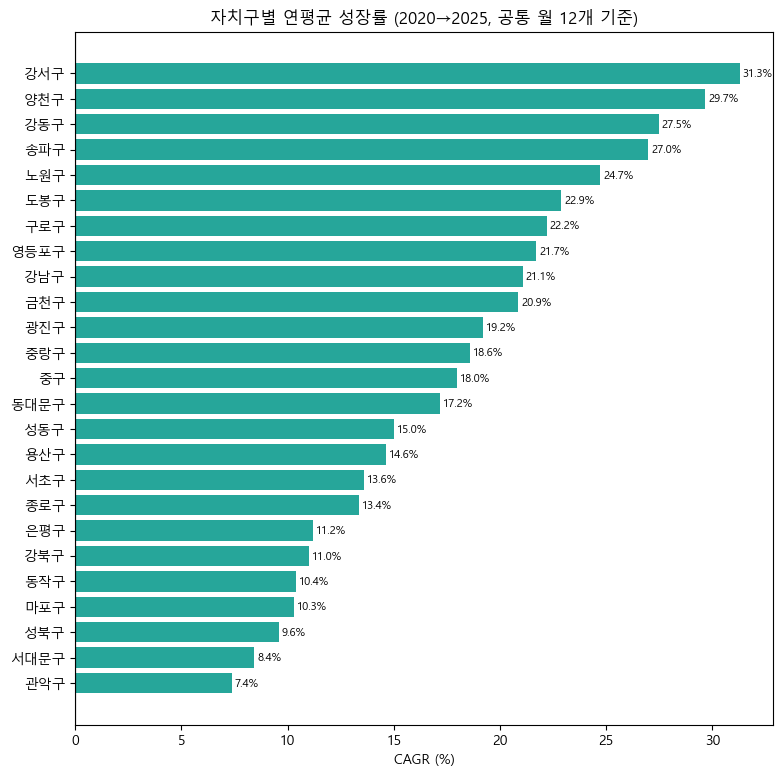

In [25]:
p = panel.dropna().assign(year=lambda d: d['date'].dt.year, month=lambda d: d['date'].dt.month)
y0, y1 = p['year'].min(), p['year'].max()
common_months = set(p.loc[p['year'] == y0, 'month']) & set(p.loc[p['year'] == y1, 'month'])
pc = p[p['month'].isin(common_months) & p['year'].isin([y0, y1])]
gu_year = pc.pivot_table(index='자치구', columns='year', values='rent', aggfunc='mean')
gu_year['CAGR(%)'] = ((gu_year[y1] / gu_year[y0]) ** (1 / (y1 - y0)) - 1) * 100
gu_year = gu_year.sort_values('CAGR(%)')

plt.figure(figsize=(9, 9))
colors = np.where(gu_year['CAGR(%)'] >= 0, '#26A69A', '#EF5350')
bars = plt.barh(gu_year.index, gu_year['CAGR(%)'], color=colors)
plt.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
plt.axvline(0, color='k', lw=0.8)
plt.title(f'자치구별 연평균 성장률 ({y0}→{y1}, 공통 월 {len(common_months)}개 기준)')
plt.xlabel('CAGR (%)')
save('F03_자치구성장률.png'); plt.show()

## 연도별 시간대 패턴 (평일·주말)

In [28]:
%pip install holidays

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 29.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [29]:
import holidays

years = city_hour['date'].dt.year.unique().tolist()
kr = holidays.KR(years=years)

HOLIDAYS = pd.to_datetime(list(kr.keys()))
print(len(HOLIDAYS), '일')
sorted(kr.items())[:10]  

111 일


[(datetime.date(2020, 1, 1), '신정연휴'),
 (datetime.date(2020, 1, 24), '설날 전날'),
 (datetime.date(2020, 1, 25), '설날'),
 (datetime.date(2020, 1, 26), '설날 다음날'),
 (datetime.date(2020, 1, 27), '설날 대체 휴일'),
 (datetime.date(2020, 3, 1), '삼일절'),
 (datetime.date(2020, 4, 15), '국회의원 선거일'),
 (datetime.date(2020, 4, 30), '부처님오신날'),
 (datetime.date(2020, 5, 5), '어린이날'),
 (datetime.date(2020, 6, 6), '현충일')]

In [30]:
HOLIDAYS = HOLIDAYS.union(pd.to_datetime(['2022-03-09', '2022-06-01']))

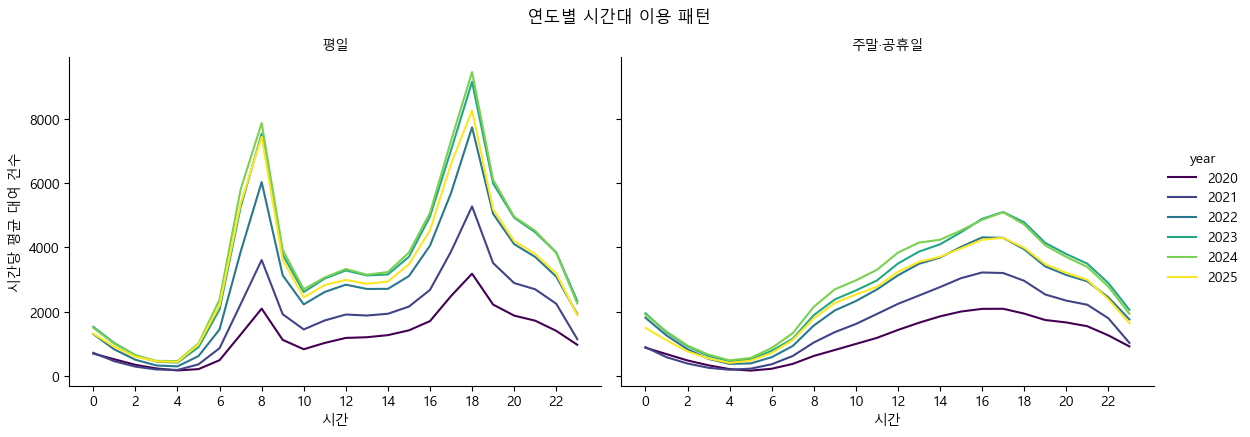

In [31]:
ch = city_hour.copy()
ch['year'] = ch['date'].dt.year
ch['daytype'] = np.where(ch['date'].dt.dayofweek.isin([5, 6]) | ch['date'].isin(HOLIDAYS), '주말·공휴일', '평일')
g = sns.relplot(data=ch, x='hour', y='cnt', hue='year', col='daytype', kind='line', palette='viridis',
                errorbar=None, height=4.2, aspect=1.4, col_order=['평일', '주말·공휴일'])
g.set_axis_labels('시간', '시간당 평균 대여 건수'); g.set_titles('{col_name}')
g.set(xticks=range(0, 24, 2)); g.fig.suptitle('연도별 시간대 이용 패턴', y=1.03)
save('F04_연도별시간대.png'); plt.show()

## 순유입 패턴: 재배치가 필요한 구와 시기

- 순유입 = 반납 − 대여. 음수(파랑)면 자전거가 빠져나가 부족, 양수(빨강)면 쌓여서 회수 필요
- 월별·요일별로 보면 재배치를 언제 어디에 집중해야 하는지 보입니다.

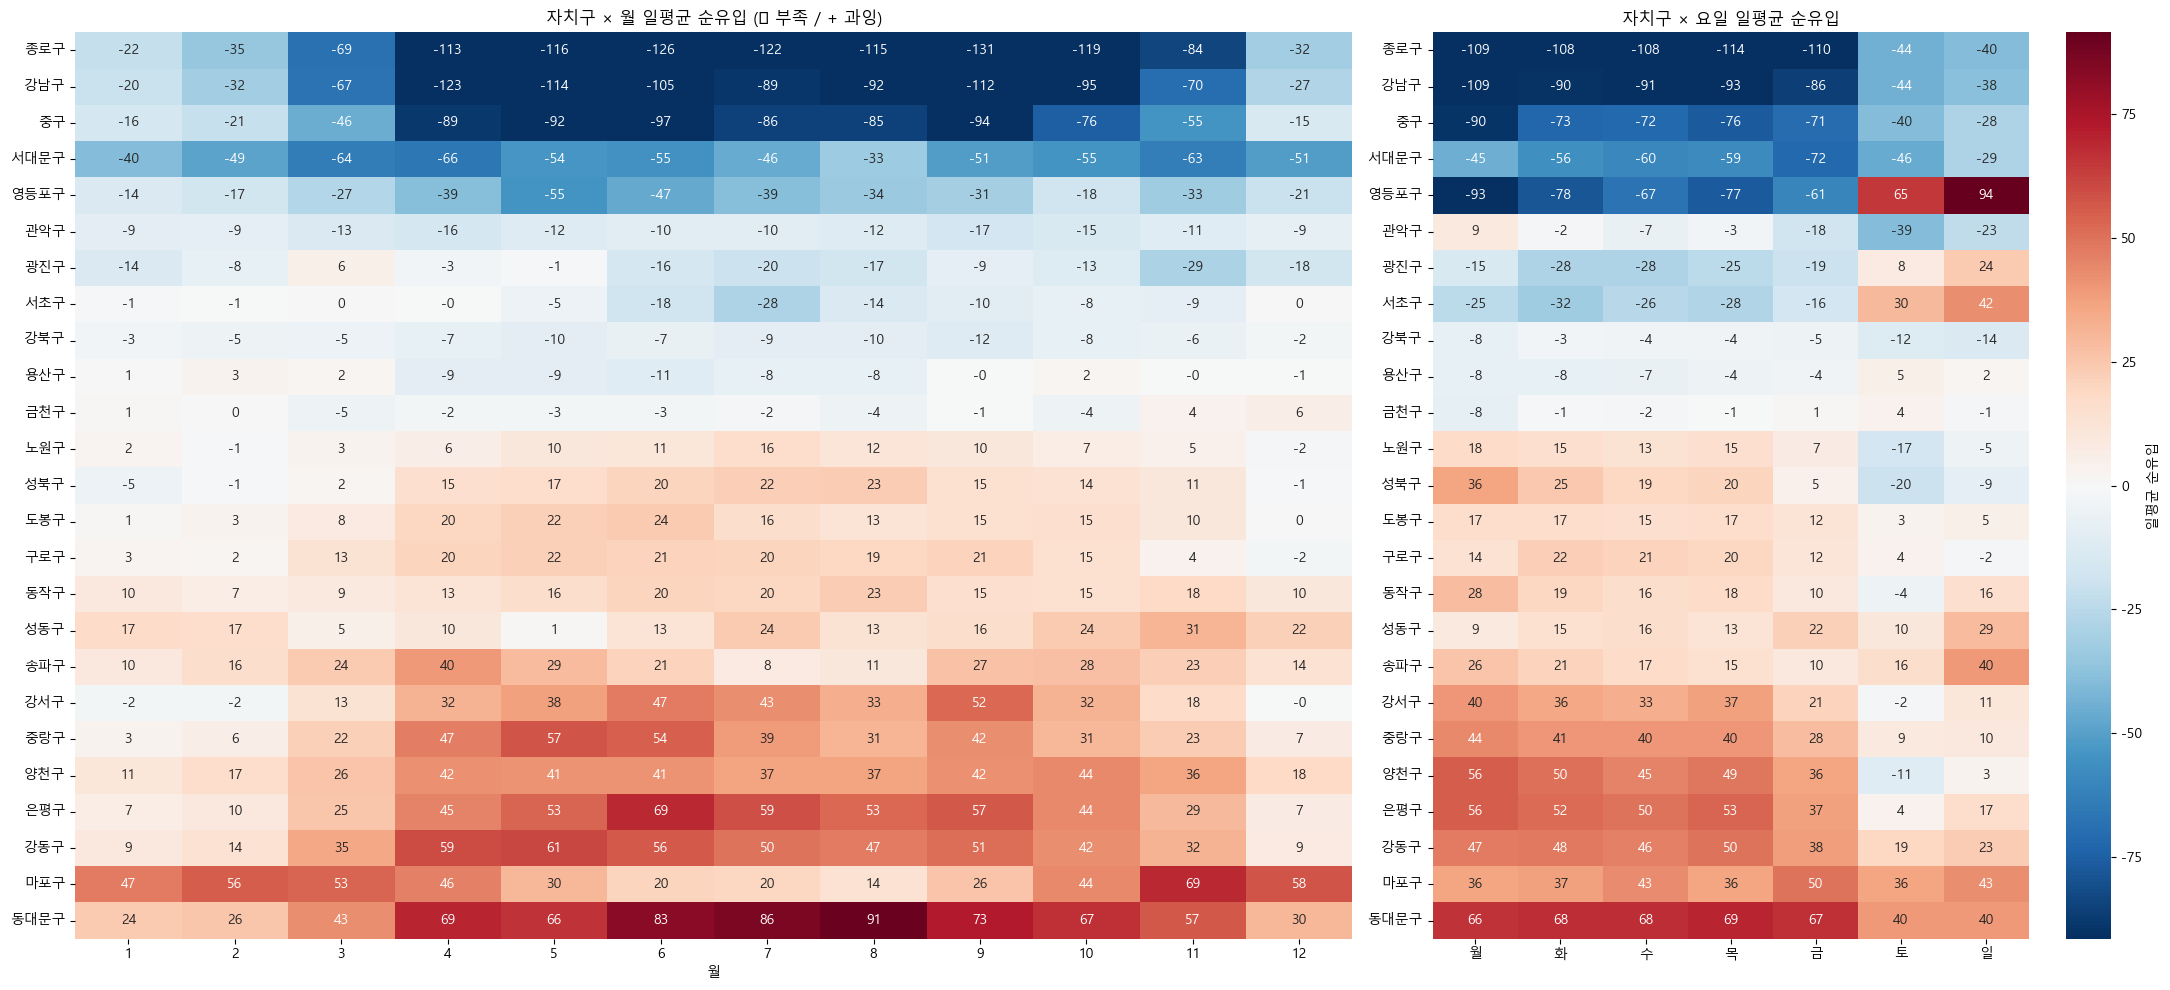

In [32]:
p['weekday'] = pd.Categorical(p['date'].dt.dayofweek.map(dict(enumerate(WEEK_ORDER))), WEEK_ORDER, ordered=True)
net_month = p.pivot_table(index='자치구', columns='month', values='net', aggfunc='mean')
net_week = p.pivot_table(index='자치구', columns='weekday', values='net', aggfunc='mean', observed=False)
order = net_month.mean(axis=1).sort_values().index
lim = np.nanpercentile(np.abs(net_month.values), 95)

fig, axes = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={'width_ratios': [12, 7]})
sns.heatmap(net_month.loc[order], annot=True, fmt='.0f', cmap='RdBu_r', center=0, vmin=-lim, vmax=lim,
            ax=axes[0], cbar=False)
axes[0].set_title('자치구 × 월 일평균 순유입 (− 부족 / + 과잉)'); axes[0].set_xlabel('월'); axes[0].set_ylabel('')
sns.heatmap(net_week.loc[order], annot=True, fmt='.0f', cmap='RdBu_r', center=0, vmin=-lim, vmax=lim,
            ax=axes[1], cbar_kws={'label': '일평균 순유입'})
axes[1].set_title('자치구 × 요일 일평균 순유입'); axes[1].set_xlabel(''); axes[1].set_ylabel('')
plt.tight_layout(); save('F07_순유입히트맵.png'); plt.show()

# 특성 공학
- 미래 날짜 행을 미리 붙여 두고 특성을 한 번에 계산합니다. 그러면 같은 함수로 학습용 특성과 "앞으로 7일" 예측용 특성이 함께 만들어집니다.
- 시차 특성은 모두 HORIZON일 이전 값만 사용해서, 예측 시점에 이미 알고 있는 정보만 들어가게 합니다 (데이터 누수 방지).
- 연중일자를 sin·cos로 바꾸는 이유: 12월 31일(365)과 1월 1일(1)은 숫자로는 멀지만 실제로는 붙어 있으므로, 원 위의 좌표로 표현해서 가깝게 만듭니다.

In [40]:
def make_features(panel, target, horizon=HORIZON, future_days=HORIZON):
    df = panel[['자치구', 'date', target]].copy()
    last = df['date'].max()
    if future_days:                                        # 예측할 미래 날짜 행 추가 (값은 NaN)
        fut = pd.MultiIndex.from_product([GUS, pd.date_range(last + pd.Timedelta(days=1), periods=future_days)],
                                         names=['자치구', 'date']).to_frame(index=False)
        df = pd.concat([df, fut], ignore_index=True)
    df = df.sort_values(['자치구', 'date']).reset_index(drop=True)
    d = df['date']

    df['dow'] = d.dt.dayofweek
    df['is_holiday'] = d.isin(HOLIDAYS).astype(int)
    df['is_offday'] = ((df['dow'] >= 5) | (df['is_holiday'] == 1)).astype(int)
    df['month'] = d.dt.month
    df['doy_sin'] = np.sin(2 * np.pi * d.dt.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * d.dt.dayofyear / 365.25)
    df['trend'] = (d - pd.Timestamp('2020-01-01')).dt.days
    df['gu_code'] = df['자치구'].map({g: i for i, g in enumerate(GUS)})

    g = df.groupby('자치구')[target]
    for lag in sorted({horizon, 7, 14, 21, 28, 364}):
        if lag >= horizon:
            df[f'lag_{lag}'] = g.shift(lag)
    shifted = g.shift(horizon)
    sg = shifted.groupby(df['자치구'])
    df['roll7'] = sg.transform(lambda s: s.rolling(7, min_periods=5).mean())
    df['roll28'] = sg.transform(lambda s: s.rolling(28, min_periods=20).mean())
    week_lags = [l for l in [7, 14, 21, 28] if l >= horizon]
    df['same_dow4'] = df[[f'lag_{l}' for l in week_lags]].mean(axis=1)
    
    city_t = df.groupby('date')[target].sum(min_count=1).rename('city')
    city_t = city_t.to_frame()
    city_t['city_lag'] = city_t['city'].shift(horizon)
    city_t['city_roll7'] = city_t['city'].shift(horizon).rolling(7, min_periods=5).mean()
    df = df.merge(city_t[['city_lag', 'city_roll7']], left_on='date', right_index=True, how='left')
    return df
    

data_rent = make_features(panel, 'rent')
FEATURES = [c for c in data_rent.columns if c not in ['자치구', 'date', 'rent']]
print('특성', len(FEATURES), '개:', FEATURES)
data_rent.dropna(subset=['lag_364']).head()

특성 18 개: ['dow', 'is_holiday', 'is_offday', 'month', 'doy_sin', 'doy_cos', 'trend', 'gu_code', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_364', 'roll7', 'roll28', 'same_dow4', 'city_lag', 'city_roll7']


,자치구,date,rent,dow,is_holiday,is_offday,month,doy_sin,doy_cos,trend,...,lag_7,lag_14,lag_21,lag_28,lag_364,roll7,roll28,same_dow4,city_lag,city_roll7
364,강남구,2020-12-30,370.0,2,0,0,12,-0.004301,0.999991,364,...,724.0,463.0,843.0,879.0,232.0,569.428571,678.857143,727.25,22273.0,17554.285714
365,강남구,2020-12-31,427.0,3,0,0,12,0.012901,0.999917,365,...,741.0,549.0,925.0,834.0,482.0,596.857143,667.107143,762.25,21750.0,18213.142857
366,강남구,2021-01-01,405.0,4,1,1,1,0.017202,0.999852,366,...,501.0,557.0,860.0,854.0,530.0,588.857143,651.428571,693.00,15243.0,18091.285714
367,강남구,2021-01-02,409.0,5,0,1,1,0.034398,0.999408,367,...,642.0,402.0,643.0,628.0,417.0,623.142857,653.428571,578.75,19805.0,19093.857143
368,강남구,2021-01-03,372.0,6,0,1,1,0.051584,0.998669,368,...,693.0,408.0,198.0,657.0,373.0,663.857143,662.178571,489.00,19676.0,20138.714286


# 시간 순서로 학습·검증·시험 분리
- 시계열은 무작위로 섞어 나누면 안 됩니다 (미래 정보로 과거를 맞히는 셈). 날짜 기준으로 앞부분은 학습, 뒷부분은 평가에 씁니다.
- lag_364가 필요하므로 첫 1년(2020년)은 특성 계산에만 쓰이고 학습 행에서는 빠집니다.

In [41]:
def split(data, target):
    known = data.dropna(subset=[target, 'lag_364', 'roll28'])
    train = known[known['date'] < VALID_START]
    valid = known[(known['date'] >= VALID_START) & (known['date'] < TEST_START)]
    test  = known[known['date'] >= TEST_START]
    future = data[data[target].isna() & (data['date'] > panel['date'].max())]
    return train, valid, test, future

train, valid, test, future = split(data_rent, 'rent')
for name, d in [('학습', train), ('검증', valid), ('시험', test), ('미래', future)]:
    print(f'{name}: {len(d):>7,}행  {d["date"].min().date()} ~ {d["date"].max().date()}')

학습:  27,425행  2020-12-30 ~ 2023-12-31
검증:   9,150행  2024-01-01 ~ 2024-12-31
시험:   9,125행  2025-01-01 ~ 2025-12-31
미래:     175행  2026-01-01 ~ 2026-01-07


# 머신러닝 모델

## 평가 지표와 기준 모델

- MAE: 평균 몇 건 틀리는지 / RMSE: 큰 오차에 더 큰 벌점 / R²: 1에 가까울수록 좋음
- WAPE = 오차 합 / 실제 합 × 100. 이용량이 0에 가까운 날이 있어도 안정적인 백분율 오차 (MAPE 대신 사용)
- 기준 모델(baseline): "1주 전 같은 요일과 같다", "최근 4주 같은 요일 평균과 같다". 복잡한 모델은 이보다 좋아야 의미가 있습니다.

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, name):
    y_true, y_pred = np.asarray(y_true), np.clip(np.asarray(y_pred), 0, None)
    return {'모델': name,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred),
            'WAPE(%)': np.abs(y_true - y_pred).sum() / y_true.sum() * 100}

results = [evaluate(valid['rent'], valid[f'lag_{max(7, HORIZON)}'], '기준: 1주 전 같은 요일'),
           evaluate(valid['rent'], valid['same_dow4'], '기준: 최근 4주 같은 요일 평균')]
pd.DataFrame(results).round(2)

,모델,MAE,RMSE,R2,WAPE(%)
0,기준: 1주 전 같은 요일,840.99,1495.62,0.68,25.98
1,기준: 최근 4주 같은 요일 평균,779.45,1245.86,0.78,24.08


# Ridge, 랜덤포레스트, LightGBM

- Ridge(선형): 자치구를 원핫 인코딩하고 수치 특성은 표준화 → Pipeline + ColumnTransformer
- 트리 모델: 스케일 조정 불필요, 자치구는 번호(gu_code)로 사용
- 이용량은 오른쪽으로 긴 꼬리 분포라서 log1p 변환한 값을 학습하고 예측 후 expm1로 되돌립니다 (TransformedTargetRegressor)
- LightGBM이 설치되어 있지 않으면 scikit-learn의 HistGradientBoostingRegressor로 자동 대체

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
try:
    from lightgbm import LGBMRegressor
    GBM = LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=63, subsample=0.8,
                        subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)
    GBM_NAME = 'LightGBM'
except ImportError:
    GBM = HistGradientBoostingRegressor(max_iter=800, learning_rate=0.05, max_leaf_nodes=63,
                                        categorical_features=[FEATURES.index('gu_code')], random_state=42)
    GBM_NAME = 'HistGradientBoosting'


In [45]:
NUM_FEATS = [c for c in FEATURES if c != 'gu_code']
def log_target(model):
    return TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1)

models = {
    'Ridge': log_target(Pipeline([
        ('prep', ColumnTransformer([('gu', OneHotEncoder(handle_unknown='ignore'), ['gu_code']),
                                    ('num', StandardScaler(), NUM_FEATS)])),
        ('model', Ridge(alpha=1.0))])),
    'RandomForest': log_target(RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                     max_features=0.5, n_jobs=-1, random_state=42)),
    GBM_NAME: log_target(GBM),
}

In [46]:
valid_pred = valid[['자치구', 'date', 'rent']].copy()
for name, model in models.items():
    t = time.time()
    model.fit(train[FEATURES], train['rent'])
    valid_pred[name] = np.clip(model.predict(valid[FEATURES]), 0, None)
    results.append(evaluate(valid['rent'], valid_pred[name], name))
    print(f'{name}: {time.time() - t:.1f}초')

result_df = pd.DataFrame(results).set_index('모델').round(2).sort_values('MAE')
result_df

Ridge: 0.1초
RandomForest: 11.5초
LightGBM: 3.7초


,MAE,RMSE,R2,WAPE(%)
모델,,,,
기준: 최근 4주 같은 요일 평균,779.45,1245.86,0.78,24.08
LightGBM,814.59,1273.44,0.76,25.17
기준: 1주 전 같은 요일,840.99,1495.62,0.68,25.98
Ridge,928.81,1721.45,0.57,28.70
RandomForest,999.02,1419.86,0.71,30.87


# 하이퍼파라미터 탐색 (시계열 교차검증)
- 일반 KFold는 미래 데이터로 학습하고 과거를 평가하게 되므로 TimeSeriesSplit을 씁니다: 학습 기간을 앞에서부터 늘려 가며 바로 다음 기간으로 평가
- 시간이 오래 걸리므로 RandomizedSearchCV로 일부 조합만 시험합니다.

In [47]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

train_sorted = train.sort_values('date')                  # 날짜순 정렬이 필수
tscv = TimeSeriesSplit(n_splits=3)
if GBM_NAME == 'LightGBM':
    param_dist = {'regressor__num_leaves': [31, 63, 127], 'regressor__learning_rate': [0.02, 0.05, 0.1],
                  'regressor__n_estimators': [400, 800, 1200], 'regressor__min_child_samples': [10, 20, 50]}
else:
    param_dist = {'regressor__max_leaf_nodes': [31, 63, 127], 'regressor__learning_rate': [0.02, 0.05, 0.1],
                  'regressor__max_iter': [400, 800], 'regressor__min_samples_leaf': [10, 20, 50]}
search = RandomizedSearchCV(log_target(GBM), param_dist, n_iter=8, cv=tscv,
                            scoring='neg_mean_absolute_error', random_state=42, n_jobs=1)
search.fit(train_sorted[FEATURES], train_sorted['rent'])
print('최적 파라미터:', search.best_params_)
print('교차검증 MAE:', round(-search.best_score_, 2))

tuned = search.best_estimator_
valid_pred[f'{GBM_NAME}(튜닝)'] = np.clip(tuned.predict(valid[FEATURES]), 0, None)
results.append(evaluate(valid['rent'], valid_pred[f'{GBM_NAME}(튜닝)'], f'{GBM_NAME}(튜닝)'))
result_df = pd.DataFrame(results).set_index('모델').round(2).sort_values('MAE')
result_df

최적 파라미터: {'regressor__num_leaves': 31, 'regressor__n_estimators': 400, 'regressor__min_child_samples': 10, 'regressor__learning_rate': 0.02}
교차검증 MAE: 932.5


,MAE,RMSE,R2,WAPE(%)
모델,,,,
기준: 최근 4주 같은 요일 평균,779.45,1245.86,0.78,24.08
LightGBM(튜닝),779.58,1244.78,0.78,24.09
LightGBM,814.59,1273.44,0.76,25.17
기준: 1주 전 같은 요일,840.99,1495.62,0.68,25.98
Ridge,928.81,1721.45,0.57,28.70
RandomForest,999.02,1419.86,0.71,30.87


## 특성 중요도
- 트리 모델이 예측할 때 어떤 정보에 많이 의존했는지 확인합니다. 모델 종류와 상관없이 쓸 수 있는 순열 중요도(그 특성을 섞었을 때 오차가 얼마나 커지는지)를 사용합니다.

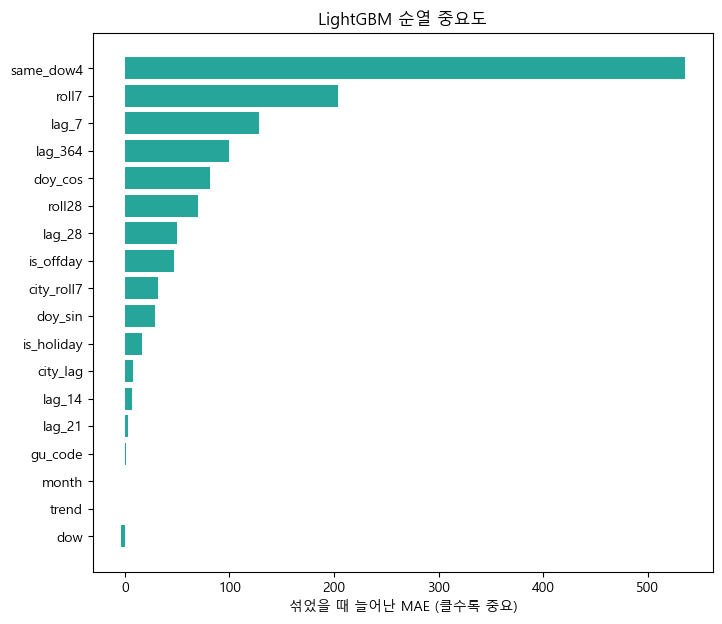

In [48]:
from sklearn.inspection import permutation_importance

best_tree = tuned
sample = valid.sample(min(5000, len(valid)), random_state=0)
imp = permutation_importance(best_tree, sample[FEATURES], sample['rent'], n_repeats=3,
                             scoring='neg_mean_absolute_error', random_state=0, n_jobs=1)
imp_s = pd.Series(imp.importances_mean, index=FEATURES).sort_values()

plt.figure(figsize=(8, 7))
plt.barh(imp_s.index, imp_s.values, color='#26A69A')
plt.xlabel('섞었을 때 늘어난 MAE (클수록 중요)'); plt.title(f'{GBM_NAME} 순열 중요도')
save('F09_특성중요도.png'); plt.show()

# 딥러닝: LSTM

- 자치구마다 **최근 56일의 일별 기록(시퀀스)**을 보고 HORIZON일 뒤 대여량을 예측
- 입력이 두 개인 함수형 API 모델
    * 입력1 (시퀀스): 최근 56일의 [대여량, 반납량, 요일 sin·cos, 휴일, 연중일자 sin·cos, (기온, 강수)]
    * 입력2 (예측하는 날의 정보): 예측일의 요일·휴일·계절 + 자치구 원핫 → 미래 날짜의 달력은 미리 알 수 있으므로 함께 넣음
- 대여·반납량은 log1p 후 학습 데이터로만 MinMax 스케일링 (데이터 누수 방지)
- 25개 구를 한 모델로 학습(글로벌 모델) → 구별 데이터가 적어도 다른 구의 패턴을 함께 배움

In [53]:
LOOKBACK = 56

seq_df = panel[['자치구', 'date', 'rent', 'ret']].copy().sort_values(['자치구', 'date'])
seq_df[['rent', 'ret']] = seq_df.groupby('자치구')[['rent', 'ret']].transform(
    lambda s: s.interpolate(limit_direction='both'))           # 결측일은 앞뒤 값으로 채움
d = seq_df['date']
seq_df['log_rent'], seq_df['log_ret'] = np.log1p(seq_df['rent']), np.log1p(seq_df['ret'])
seq_df['dow_sin'], seq_df['dow_cos'] = np.sin(2 * np.pi * d.dt.dayofweek / 7), np.cos(2 * np.pi * d.dt.dayofweek / 7)
seq_df['offday'] = ((d.dt.dayofweek >= 5) | d.isin(HOLIDAYS)).astype(float)
seq_df['doy_sin'], seq_df['doy_cos'] = np.sin(2 * np.pi * d.dt.dayofyear / 365.25), np.cos(2 * np.pi * d.dt.dayofyear / 365.25)
SEQ_COLS = ['log_rent', 'log_ret', 'dow_sin', 'dow_cos', 'offday', 'doy_sin', 'doy_cos']
AUX_DAY_COLS = ['dow_sin', 'dow_cos', 'offday', 'doy_sin', 'doy_cos']   # 예측일의 달력 정보

train_mask = seq_df['date'] < VALID_START
mins, maxs = seq_df.loc[train_mask, SEQ_COLS].min(), seq_df.loc[train_mask, SEQ_COLS].max()
scaled = (seq_df[SEQ_COLS] - mins) / (maxs - mins + 1e-9)
seq_df[[c + '_s' for c in SEQ_COLS]] = scaled.values


def make_windows(seq_df, lookback=LOOKBACK, horizon=HORIZON):
    Xs, Xa, ys, keys = [], [], [], []
    eye = np.eye(len(GUS))
    for gi, gu in enumerate(GUS):
        g = seq_df[seq_df['자치구'] == gu].reset_index(drop=True)
        arr = g[[c + '_s' for c in SEQ_COLS]].values.astype('float32')
        aux = g[[c + '_s' for c in AUX_DAY_COLS]].values.astype('float32')
        y = g['log_rent'].values.astype('float32')
        for t in range(lookback - 1, len(g) - horizon):          # t = 마지막 관측일
            tgt = t + horizon                                    # 예측하는 날
            Xs.append(arr[t - lookback + 1: t + 1])
            Xa.append(np.concatenate([aux[tgt], eye[gi]]))
            ys.append(y[tgt]); keys.append((gu, g.loc[tgt, 'date']))
    keys = pd.DataFrame(keys, columns=['자치구', 'date'])
    return np.stack(Xs), np.stack(Xa), np.array(ys), keys

Xs, Xa, ys, keys = make_windows(seq_df)

known = keys.merge(panel[['자치구', 'date', 'rent']], on=['자치구', 'date'], how='left')['rent'].notna().values
tr = known & (keys['date'] < VALID_START).values & (keys['date'] >= train['date'].min()).values
va = known & ((keys['date'] >= VALID_START) & (keys['date'] < TEST_START)).values
te = known & (keys['date'] >= TEST_START).values
print('시퀀스 입력', Xs.shape, '| 보조 입력', Xa.shape, '| 학습', tr.sum(), '검증', va.sum(), '시험', te.sum())

시퀀스 입력 (53250, 56, 7) | 보조 입력 (53250, 30) | 학습 27425 검증 9150 시험 9125


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 sequence (InputLayer)          [(None, 56, 7)]      0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 56, 64)       18432       ['sequence[0][0]']               
                                                                                                  
 dropout (Dropout)              (None, 56, 64)       0           ['lstm[0][0]']                   
                                                                                                  
 target_day (InputLayer)        [(None, 30)]         0           []                               
                                                                                              

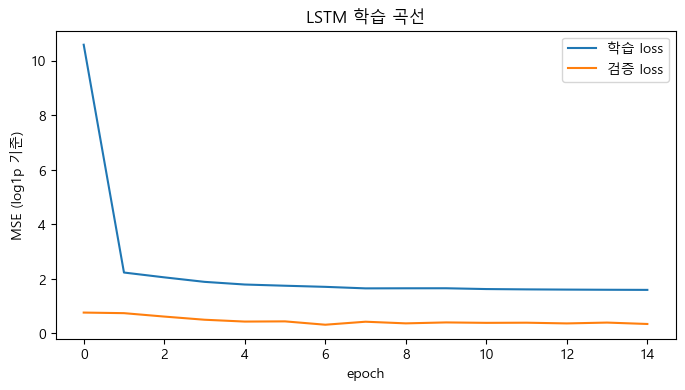

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
tf.random.set_seed(42)

seq_in = Input(shape=(LOOKBACK, Xs.shape[2]), name='sequence')
x = LSTM(64, return_sequences=True)(seq_in)
x = Dropout(0.2)(x)
x = LSTM(32)(x)
aux_in = Input(shape=(Xa.shape[1],), name='target_day')
a = Dense(16, activation='relu')(aux_in)
h = Concatenate()([x, a])
h = Dense(32, activation='relu')(h)
h = Dropout(0.2)(h)
out = Dense(1)(h)                                           # log1p(대여량) 예측
lstm = Model(inputs=[seq_in, aux_in], outputs=out)
lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
lstm.summary()

ckpt = os.path.join(OUT_DIR, 'lstm_rent_best.h5')
hist = lstm.fit([Xs[tr], Xa[tr]], ys[tr], validation_data=([Xs[va], Xa[va]], ys[va]),
                epochs=60, batch_size=256, verbose=2,
                callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
                           ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
                           ModelCheckpoint(ckpt, monitor='val_loss', save_best_only=True)])

plt.figure(figsize=(8, 4))
plt.plot(hist.history['loss'], label='학습 loss'); plt.plot(hist.history['val_loss'], label='검증 loss')
plt.xlabel('epoch'); plt.ylabel('MSE (log1p 기준)'); plt.legend(); plt.title('LSTM 학습 곡선')
save('F10_LSTM학습곡선.png'); plt.show()

In [55]:
def lstm_predict(mask):
    return np.expm1(lstm.predict([Xs[mask], Xa[mask]], verbose=0).ravel()).clip(0)

lstm_valid = keys[va].assign(LSTM=lstm_predict(va))
valid_pred = valid_pred.merge(lstm_valid, on=['자치구', 'date'], how='left')
results.append(evaluate(valid_pred['rent'], valid_pred['LSTM'].fillna(valid_pred['rent']), 'LSTM'))
result_df = pd.DataFrame(results).set_index('모델').round(2).sort_values('MAE')
result_df

,MAE,RMSE,R2,WAPE(%)
모델,,,,
기준: 최근 4주 같은 요일 평균,779.45,1245.86,0.78,24.08
LightGBM(튜닝),779.58,1244.78,0.78,24.09
LightGBM,814.59,1273.44,0.76,25.17
기준: 1주 전 같은 요일,840.99,1495.62,0.68,25.98
Ridge,928.81,1721.45,0.57,28.70
RandomForest,999.02,1419.86,0.71,30.87
LSTM,1414.58,2098.78,0.36,43.71


# 모델 비교, 앙상블, 시험 데이터 평가

- 검증 성능이 가장 좋은 머신러닝 모델과 LSTM을 평균 낸 앙상블도 비교합니다. 성격이 다른 모델은 틀리는 방향이 달라서 평균하면 오차가 줄어드는 경우가 많습니다

- 모델 선택은 검증 데이터로 끝내고, 시험 데이터는 마지막에 한 번만 평가합니다.

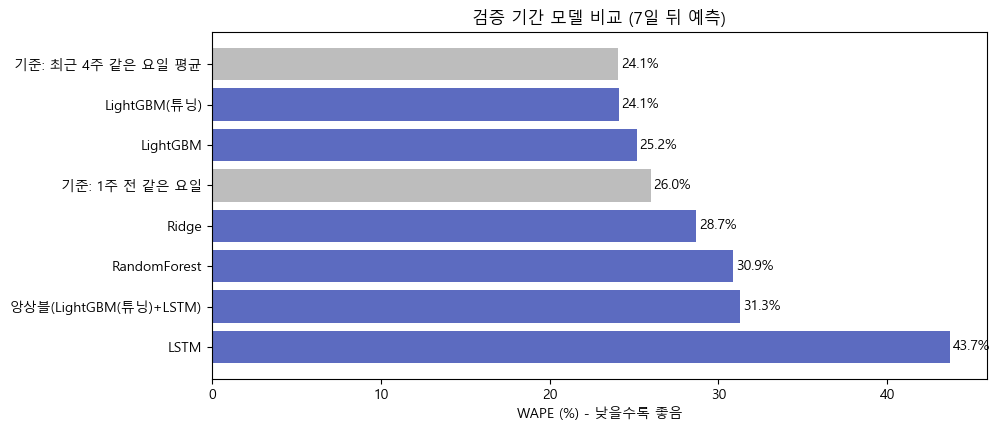

검증 기준 최고 머신러닝 모델: LightGBM(튜닝)


,MAE,RMSE,R2,WAPE(%)
모델,,,,
기준: 최근 4주 같은 요일 평균,779.45,1245.86,0.78,24.08
LightGBM(튜닝),779.58,1244.78,0.78,24.09
LightGBM,814.59,1273.44,0.76,25.17
기준: 1주 전 같은 요일,840.99,1495.62,0.68,25.98
Ridge,928.81,1721.45,0.57,28.70
RandomForest,999.02,1419.86,0.71,30.87
앙상블(LightGBM(튜닝)+LSTM),1012.32,1508.28,0.67,31.28
LSTM,1414.58,2098.78,0.36,43.71


In [56]:
ml_cols = [c for c in valid_pred.columns if c not in ['자치구', 'date', 'rent', 'LSTM']]
best_ml = min(ml_cols, key=lambda c: mean_absolute_error(valid_pred['rent'], valid_pred[c]))
has_lstm = 'LSTM' in valid_pred and valid_pred['LSTM'].notna().any()
if has_lstm:
    valid_pred['앙상블'] = valid_pred[[best_ml, 'LSTM']].mean(axis=1)
    results.append(evaluate(valid_pred['rent'], valid_pred['앙상블'], f'앙상블({best_ml}+LSTM)'))
result_df = pd.DataFrame(results).set_index('모델').round(2).sort_values('MAE')

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#BDBDBD' if n.startswith('기준') else '#5C6BC0' for n in result_df.index]
bars = ax.barh(result_df.index[::-1], result_df['WAPE(%)'][::-1], color=colors[::-1])
ax.bar_label(bars, fmt='%.1f%%', padding=2)
ax.set_xlabel('WAPE (%) - 낮을수록 좋음'); ax.set_title(f'검증 기간 모델 비교 ({HORIZON}일 뒤 예측)')
save('F11_모델비교.png'); plt.show()
print('검증 기준 최고 머신러닝 모델:', best_ml)
result_df

In [57]:
final_name = best_ml
final_model = tuned if final_name.endswith('(튜닝)') else models[final_name]
train_valid = pd.concat([train, valid])
final_model.fit(train_valid[FEATURES], train_valid['rent'])

test_pred = test[['자치구', 'date', 'rent']].copy()
test_pred['ML'] = np.clip(final_model.predict(test[FEATURES]), 0, None)
test_res = [evaluate(test['rent'], test[f'lag_{max(7, HORIZON)}'], '기준: 1주 전 같은 요일'),
            evaluate(test_pred['rent'], test_pred['ML'], final_name)]
if has_lstm:
    test_pred = test_pred.merge(keys[te].assign(LSTM=lstm_predict(te)), on=['자치구', 'date'], how='left')
    test_pred['LSTM'] = test_pred['LSTM'].fillna(test_pred['ML'])
    test_pred['앙상블'] = test_pred[['ML', 'LSTM']].mean(axis=1)
    test_res += [evaluate(test_pred['rent'], test_pred['LSTM'], 'LSTM'),
                 evaluate(test_pred['rent'], test_pred['앙상블'], '앙상블')]
pd.DataFrame(test_res).set_index('모델').round(2)

,MAE,RMSE,R2,WAPE(%)
모델,,,,
기준: 1주 전 같은 요일,801.83,1385.22,0.67,28.11
LightGBM(튜닝),846.00,1256.68,0.72,29.66
LSTM,1118.27,1705.04,0.49,39.20
앙상블,955.15,1411.09,0.65,33.48


# 예측 결과 시각화와 오차 분석

- 서울 전체 합계와 주요 자치구의 실제·예측을 비교하고, 어느 구·요일·월에서 많이 틀리는지 확인합니다.

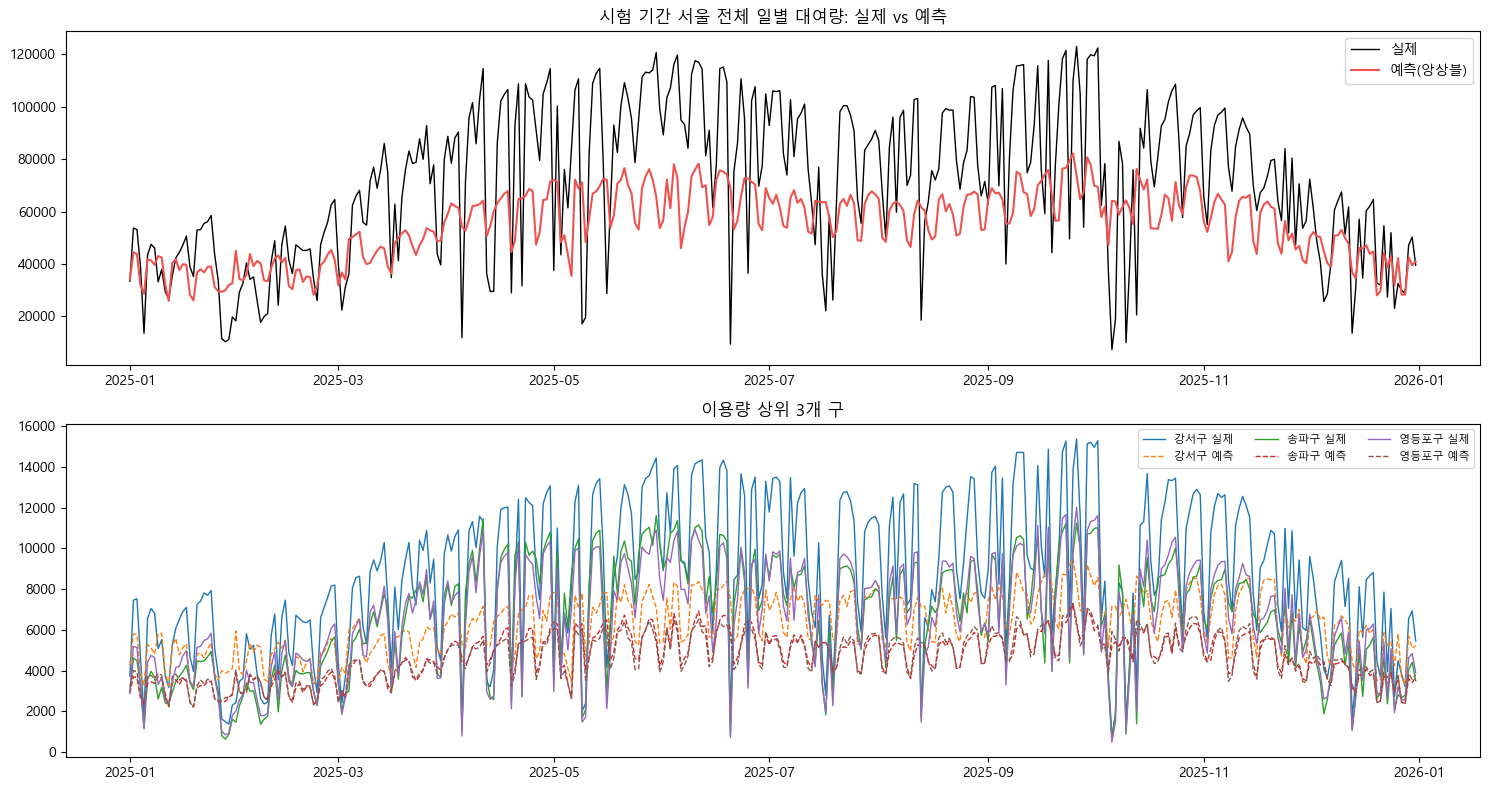

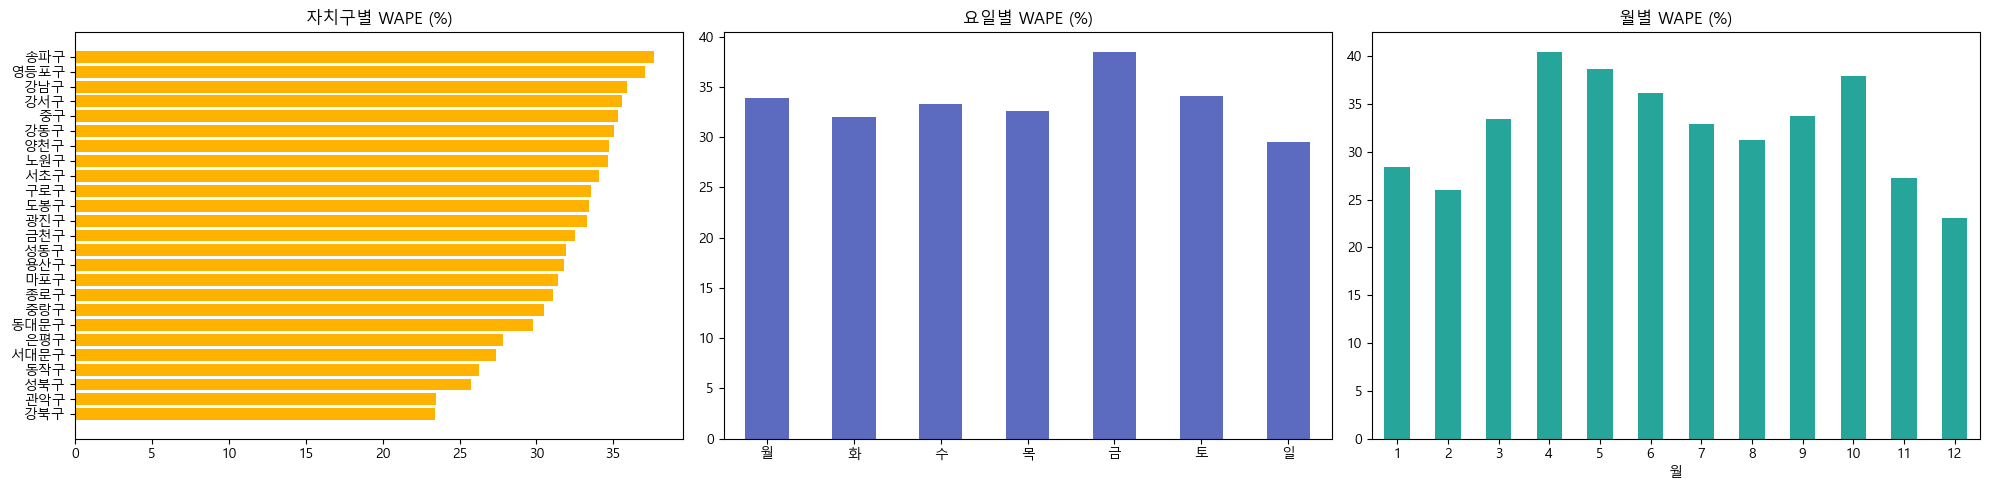

In [58]:
pred_col = '앙상블' if has_lstm else 'ML'
tp = test_pred.copy()
city_tp = tp.groupby('date')[['rent', pred_col]].sum()

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(city_tp.index, city_tp['rent'], label='실제', color='k', lw=1)
axes[0].plot(city_tp.index, city_tp[pred_col], label=f'예측({pred_col})', color='#EF5350', lw=1.5)
axes[0].set_title('시험 기간 서울 전체 일별 대여량: 실제 vs 예측'); axes[0].legend()
for gu in tp.groupby('자치구')['rent'].sum().nlargest(3).index:
    g = tp[tp['자치구'] == gu].set_index('date')
    axes[1].plot(g.index, g['rent'], lw=1, label=f'{gu} 실제')
    axes[1].plot(g.index, g[pred_col], lw=1, ls='--', label=f'{gu} 예측')
axes[1].set_title('이용량 상위 3개 구'); axes[1].legend(ncol=3, fontsize=8)
plt.tight_layout(); save('F12_실제vs예측.png'); plt.show()

tp['abs_err'] = (tp['rent'] - tp[pred_col]).abs()
tp['weekday'] = pd.Categorical(tp['date'].dt.dayofweek.map(dict(enumerate(WEEK_ORDER))), WEEK_ORDER, ordered=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
gu_err = tp.groupby('자치구').apply(lambda d: d['abs_err'].sum() / d['rent'].sum() * 100).sort_values()
axes[0].barh(gu_err.index, gu_err.values, color='#FFB300'); axes[0].set_title('자치구별 WAPE (%)')
tp.groupby('weekday', observed=False).apply(lambda d: d['abs_err'].sum() / d['rent'].sum() * 100).plot(
    kind='bar', ax=axes[1], color='#5C6BC0', rot=0)
axes[1].set_title('요일별 WAPE (%)'); axes[1].set_xlabel('')
tp.groupby(tp['date'].dt.month).apply(lambda d: d['abs_err'].sum() / d['rent'].sum() * 100).plot(
    kind='bar', ax=axes[2], color='#26A69A', rot=0)
axes[2].set_title('월별 WAPE (%)'); axes[2].set_xlabel('월')
plt.tight_layout(); save('F13_오차분석.png'); plt.show()

# 재배치 계획: 순유입 예측

- 재배치에 필요한 값은 순유입 = 반납 − 대여입니다. 두 가지 방법을 비교.
    * 방법 A (차이 방식): 대여 모델과 반납 모델을 따로 만들고 예측값의 차이를 계산
    * 방법 B (직접 방식): 순유입 자체를 목표값으로 하는 모델을 바로 학습
- 유입은 큰 두 수(대여·반납 수천 건)의 작은 차이(수십 건)라서, 방법 A는 두 모델의 오차가 그대로 더해져 방향(부족/과잉)까지 틀리기 쉽다. 또 log1p로 학습한 모델은 예측이 약간 작게 나오는 경향이 있어 차이에 치우침이 생긴다. 그래서 방법 B를 재배치 계획에 사용.

- 순유입은 음수가 있으므로 log 변환 없이 학습

In [59]:
from sklearn.base import clone

In [60]:
data_ret = make_features(panel, 'ret')
tr_r, va_r, te_r, fu_r = split(data_ret, 'ret')
ret_model = clone(final_model).fit(pd.concat([tr_r, va_r])[FEATURES], pd.concat([tr_r, va_r])['ret'])

In [61]:
data_net = make_features(panel, 'net')
tr_n, va_n, te_n, fu_n = split(data_net, 'net')
base_reg = final_model.regressor if hasattr(final_model, 'regressor') else final_model
net_model = clone(base_reg).fit(pd.concat([tr_n, va_n])[FEATURES], pd.concat([tr_n, va_n])['net'])

net_test = (test_pred[['자치구', 'date', 'rent', 'ML']]
            .merge(te_r[['자치구', 'date', 'ret']].assign(ret_pred=np.clip(ret_model.predict(te_r[FEATURES]), 0, None)),
                   on=['자치구', 'date'])
            .merge(te_n[['자치구', 'date']].assign(net_B=net_model.predict(te_n[FEATURES])), on=['자치구', 'date']))
net_test['net'] = net_test['ret'] - net_test['rent']
net_test['net_A'] = net_test['ret_pred'] - net_test['ML']

rows = []

                    MAE(대/일)  부족·과잉 방향 일치율  구별 평균 상관계수
방법                                                    
방법 A: 대여·반납 차이       107.192         0.563       0.514
방법 B: 순유입 직접 예측       32.665         0.736       0.998
기준: 최근 4주 같은 요일 평균    36.246         0.714         NaN


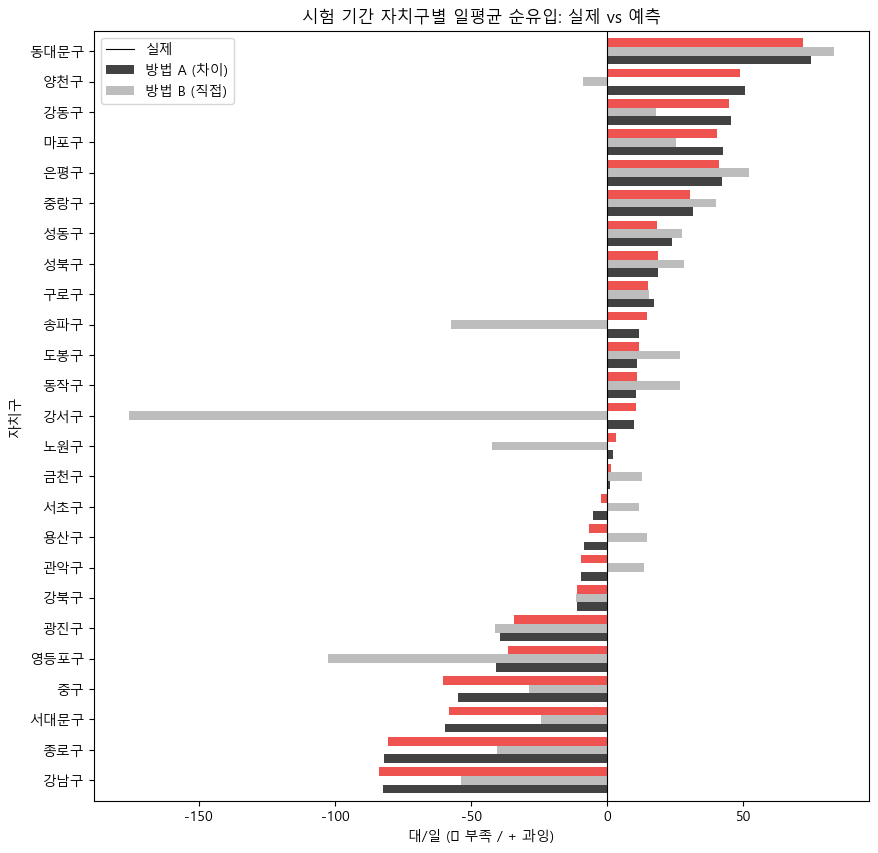

In [62]:
for col, name in [('net_A', '방법 A: 대여·반납 차이'), ('net_B', '방법 B: 순유입 직접 예측')]:
    gu_mean = net_test.groupby('자치구')[['net', col]].mean()
    rows.append({'방법': name,
                 'MAE(대/일)': mean_absolute_error(net_test['net'], net_test[col]),
                 '부족·과잉 방향 일치율': (np.sign(net_test['net']) == np.sign(net_test[col])).mean(),
                 '구별 평균 상관계수': gu_mean.corr().iloc[0, 1]})
rows.append({'방법': '기준: 최근 4주 같은 요일 평균',
             'MAE(대/일)': mean_absolute_error(te_n['net'], te_n['same_dow4']),
             '부족·과잉 방향 일치율': (np.sign(te_n['net']) == np.sign(te_n['same_dow4'])).mean(),
             '구별 평균 상관계수': np.nan})
net_compare = pd.DataFrame(rows).set_index('방법')
print(net_compare.round(3))

gu_net = net_test.groupby('자치구')[['net', 'net_A', 'net_B']].mean().sort_values('net')
ax = gu_net.plot(kind='barh', figsize=(10, 10), color=['#424242', '#BDBDBD', '#EF5350'], width=0.85)
ax.axvline(0, color='k', lw=0.8); ax.legend(['실제', '방법 A (차이)', '방법 B (직접)'])
ax.set_title('시험 기간 자치구별 일평균 순유입: 실제 vs 예측'); ax.set_xlabel('대/일 (− 부족 / + 과잉)')
save('F14_순유입실제예측.png'); plt.show()

# 앞으로 7일 재배치 계획표

- 마지막 날짜 다음 날부터 HORIZON일 동안의 자치구별 예측
- 예측 대여량은 대여 모델, 예측 순유입은 방법 B 모델, 예측 반납량 = 예측 대여량 + 예측 순유입
- 공급 필요량 = 부족한 만큼(순유입이 음수), 회수 가능량 = 쌓이는 만큼(양수)

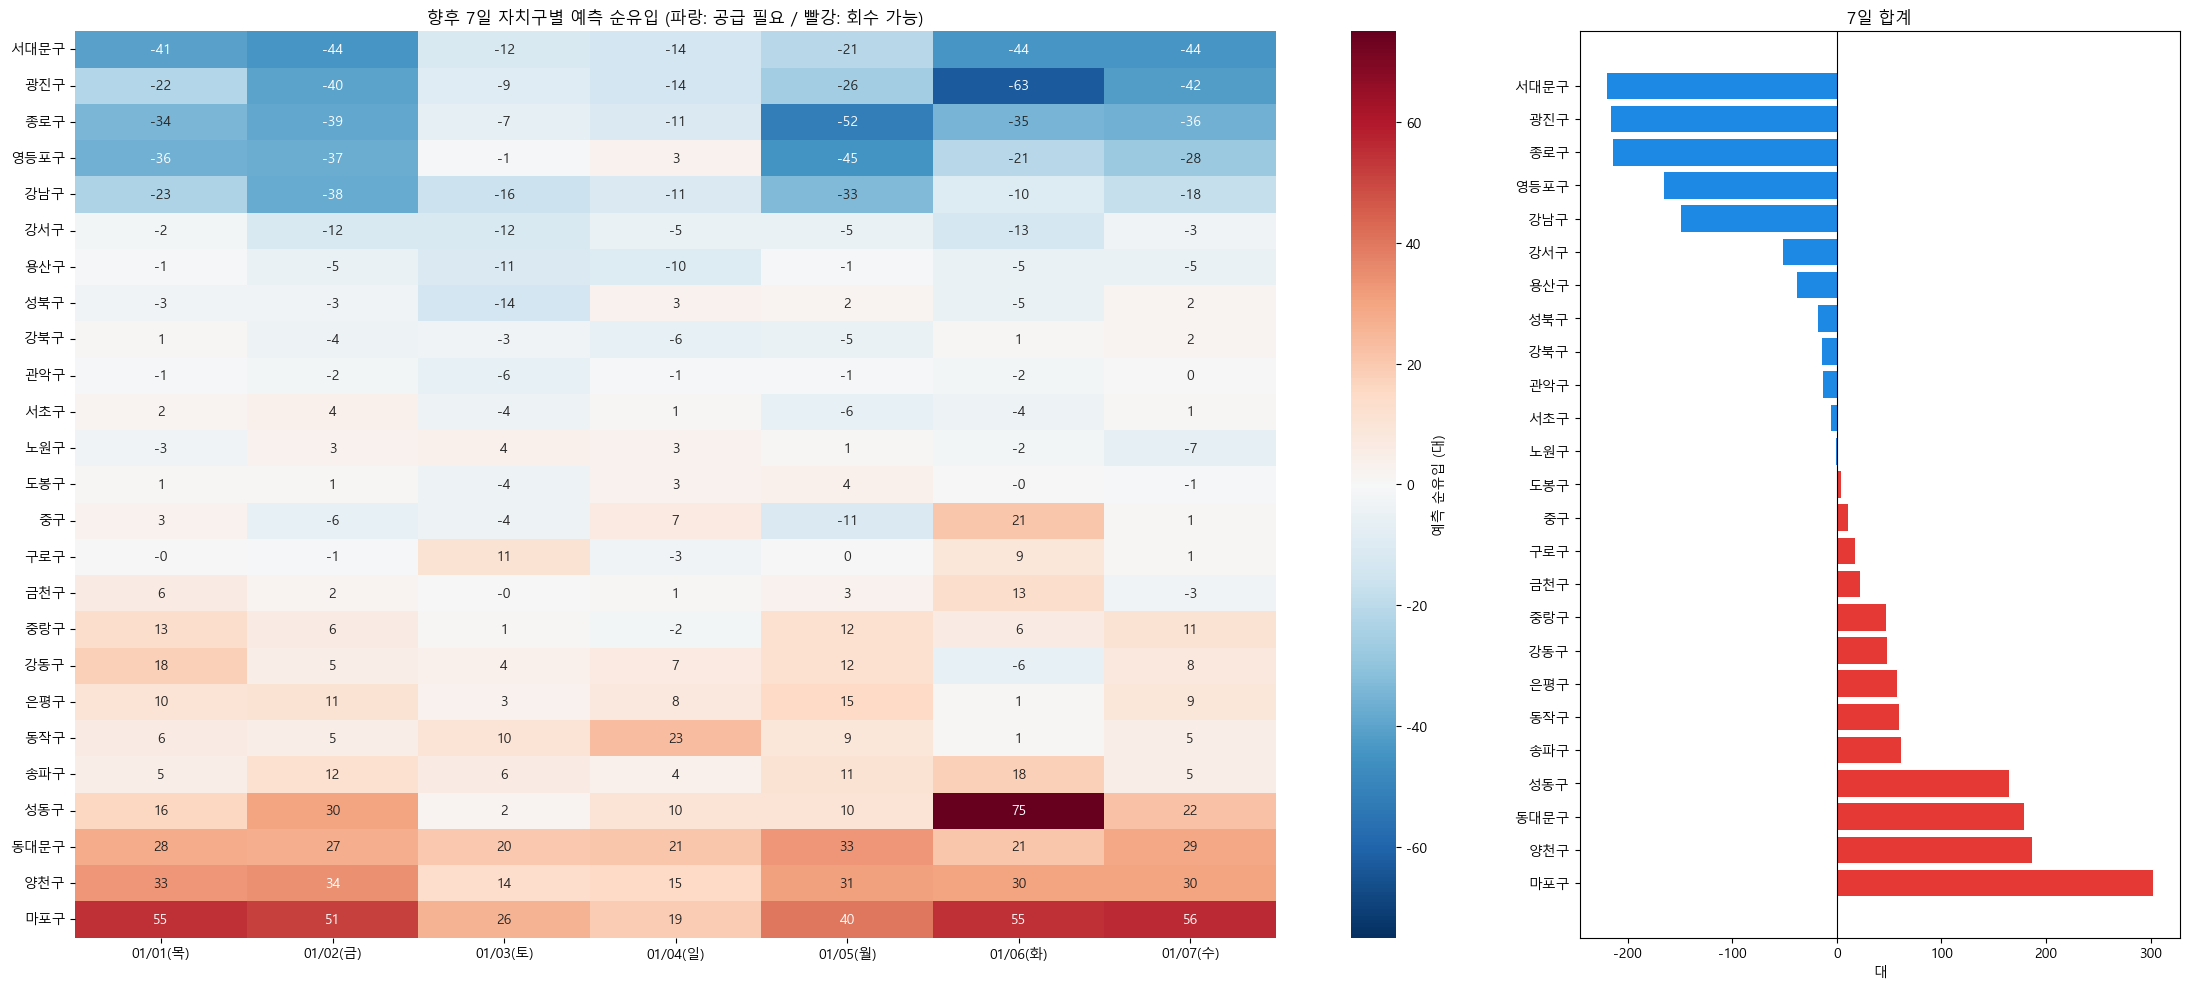

,pred_rent,pred_ret,공급필요,회수가능,순수요(공급-회수)
자치구,,,,,
서대문구,5608,5389,220,0,220
광진구,14544,14329,216,0,216
종로구,10324,10109,214,0,214
영등포구,25533,25366,168,3,165
강남구,9794,9646,149,0,149
강서구,36903,36852,52,0,52
용산구,4979,4943,38,0,38
성북구,5851,5833,25,7,18
강북구,3736,3724,18,4,14


In [63]:
plan = future[['자치구', 'date']].assign(pred_rent=np.clip(final_model.predict(future[FEATURES]), 0, None))
plan = plan.merge(fu_n[['자치구', 'date']].assign(pred_net=net_model.predict(fu_n[FEATURES])), on=['자치구', 'date'])
plan['pred_ret'] = (plan['pred_rent'] + plan['pred_net']).clip(lower=0)
plan['공급필요'] = (-plan['pred_net']).clip(lower=0).round()
plan['회수가능'] = plan['pred_net'].clip(lower=0).round()
plan[['pred_rent', 'pred_ret', 'pred_net']] = plan[['pred_rent', 'pred_ret', 'pred_net']].round()

net_pv = plan.pivot(index='자치구', columns='date', values='pred_net')
net_pv.columns = [f'{d:%m/%d}({WEEK_ORDER[d.dayofweek]})' for d in net_pv.columns]
net_pv = net_pv.loc[net_pv.sum(axis=1).sort_values().index]
lim = np.abs(net_pv.values).max()

fig, axes = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={'width_ratios': [3, 1.2]})
sns.heatmap(net_pv, annot=True, fmt='.0f', cmap='RdBu_r', center=0, vmin=-lim, vmax=lim, ax=axes[0],
            cbar_kws={'label': '예측 순유입 (대)'})
axes[0].set_title(f'향후 {HORIZON}일 자치구별 예측 순유입 (파랑: 공급 필요 / 빨강: 회수 가능)')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
total = net_pv.sum(axis=1)
axes[1].barh(total.index, total.values, color=np.where(total < 0, '#1E88E5', '#E53935'))
axes[1].axvline(0, color='k', lw=0.8); axes[1].invert_yaxis()
axes[1].set_title(f'{HORIZON}일 합계'); axes[1].set_xlabel('대')
plt.tight_layout(); save('F15_재배치계획.png'); plt.show()

summary = plan.groupby('자치구')[['pred_rent', 'pred_ret', '공급필요', '회수가능']].sum()
summary['순수요(공급-회수)'] = summary['공급필요'] - summary['회수가능']
summary = summary.sort_values('순수요(공급-회수)', ascending=False)
plan.to_csv(os.path.join(OUT_DIR, f'재배치계획_{HORIZON}일.csv'), index=False, encoding='utf-8-sig')
summary.astype(int)

In [64]:
import joblib
joblib.dump({'rent_model': final_model, 'net_model': net_model, 'ret_model': ret_model, 'features': FEATURES, 'gus': GUS,
             'horizon': HORIZON}, os.path.join(OUT_DIR, 'demand_models.joblib'), compress=3)
if has_lstm:
    lstm.save(os.path.join(OUT_DIR, 'lstm_rent.h5'))
print('저장 완료:', os.listdir(OUT_DIR))


저장 완료: ['agg_city_hour.csv', 'agg_rent_daily.csv', 'agg_return_daily.csv', 'demand_models.joblib', 'F01_연도별월이용량.png', 'F02_연도월히트맵.png', 'F03_자치구성장률.png', 'F04_연도별시간대.png', 'F07_순유입히트맵.png', 'lstm_rent.h5', 'lstm_rent_best.h5', '재배치계획_7일.csv']
